# Introduction to Gaussian Processes

**Goal of this tutorial:** build up an intuitive + mathematical understanding of Gaussian Processes (GPs), see how the kernel hyperparameters shape what a GP believes about a function, and see the standard GP regression recipe in code.

## 1. Motivation

Standard parametric regression picks a fixed functional form (a line, a polynomial, etc) and fits its parameters to data. A **Gaussian Process** instead puts a probability distribution directly over *functions*, before seeing any data. By doing this it can describe a whole family of plausible functions, and after seeing data, it narrows that family down to the ones that match the observations.

Instead of describing functions via weights and biases that you tune, we describe them via a **kernel**, which tells us how correlated the function's values are at any two input points. Nearby points -> highly correlated outputs (smooth function). Far apart points -> weakly correlated.

## 2. Kernels

A kernel is a symmetric function that computes the inner product of two points after mapping them into some feature space:

$$k(x, x') = \phi(x)^T \phi(x')$$

The whole point of a kernel is that we never have to build $\phi(x)$ explicitly so we can just evaluate $k$ directly.

**Two common types**
- *Stationary*: $k(x,x') = k(x - x')$: depends on the difference between points.
- *Homogeneous*: $k(x,x') = k(\|x-x'\|)$: depends only on distance.

**The kernel we'll use throughout: the RBF kernel (also called the gaussian kernel)**

$$k(x, x') = \sigma_f^2 \exp\!\left(-\frac{\|x-x'\|^2}{2l^2}\right)$$

Where
- $\sigma_f^2$ is the output scale, describing how far the function can wander from its mean.
- $l$ is the length scale, describing how quickly the function can change.

**Validity requirement.** A function $k$ is a valid kernel only if its Gram matrix $G_{ij} = k(x_i, x_j)$ is positive semi-definite for any choice of points, i.e. $z^T G z \ge 0$ for all $z$. This guarantees the resulting covariance matrix is a legitimate covariance matrix.

**Building new kernels from old ones.** If $k_1, k_2$ are valid kernels, then so it: 
- $c\cdot k_1$ for $c>0$
- $f(x)k_1(x,x')f(x')$ for any function $f$ 
- $k_1+k_2$
- $k_1 \cdot k_2$
- $\exp(k_1)$ 

This is useful later if we want to combine them.

## 3. Gaussian Processes: Definition

A **Gaussian Process** is a probability distribution over functions $y(x)$ such that the values of the function at any finite collection of input points $x_1,\ldots,x_N$ are jointly Gaussian.

A GP is fully specified by:
- a **mean function**: $m(x)$ (we take this as 0 for simplicity which is standard)
- a **covariance function**: the kernel $k(x,x')$.

We write $y(\cdot) \sim \mathcal{GP}(0, k(\cdot,\cdot))$.

**Why this is useful.** A function has infinitely many values. The GP sidesteps this because we only ever need to evaluate it at a finite set of points (e.g. our observation times), and at those points it behaves like an ordinary multivariate Gaussian, which we already know how to sample from and condition on.

**More clearly:** pick any $N$ points $x_1,\ldots,x_N$. The GP says the stacked function values there follow a multivariate normal:

$$\mathbf{y} = \big(y(x_1),\ldots,y(x_N)\big)^T \sim \mathcal{N}(0, K), \qquad K_{ij} = k(x_i,x_j)$$

where $K$ is the $N\times N$ matrix from plugging every pair of points into the kernel. So sampling a function just means: build $K$ from the points you  observe, then draw once from $\mathcal{N}(0,K)$

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def rbf_kernel(x1, x2, sigma_f=1.0, length_scale=1.0):
    '''RBF / squared-exponential kernel matrix between two sets of 1D points.'''
    x1 = np.atleast_1d(x1).reshape(-1, 1)
    x2 = np.atleast_1d(x2).reshape(-1, 1)
    sqdist = (x1 - x2.T) ** 2
    return sigma_f**2 * np.exp(-0.5 * sqdist / length_scale**2)

def sample_gp_prior(x_grid, sigma_f=1.0, length_scale=1.0, n_samples=5, jitter=1e-8, seed=0):
    '''Draw sample functions from GP(0, k) evaluated on x_grid.'''
    rng = np.random.default_rng(seed)
    K = rbf_kernel(x_grid, x_grid, sigma_f, length_scale) + jitter * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    z = rng.standard_normal((len(x_grid), n_samples))
    return L @ z  # each column is one sampled function

## 4. Demo: Sampling Functions from the GP Prior

Before seeing any data, here are five random functions drawn from a GP prior with a fixed length scale and output scale. Important: no data yet, this just draws from the prior.

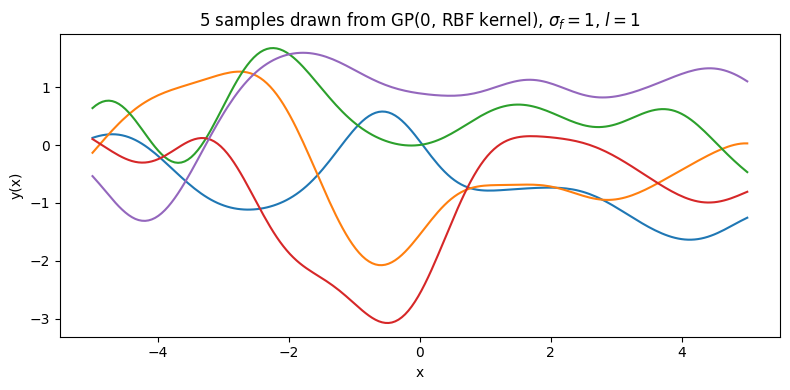

In [6]:
x_grid = np.linspace(-5, 5, 200)
samples = sample_gp_prior(x_grid, sigma_f=1.0, length_scale=1.0, n_samples=5)

plt.figure(figsize=(8, 4))
plt.plot(x_grid, samples)
plt.title("5 samples drawn from GP(0, RBF kernel), $\\sigma_f=1$, $l=1$")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.tight_layout()
plt.show()

## 5. Demo: Effect of the Kernel Hyperparameters

The kernel hyperparameters directly control what kinds of functions the GP considers plausible before any data is seen.

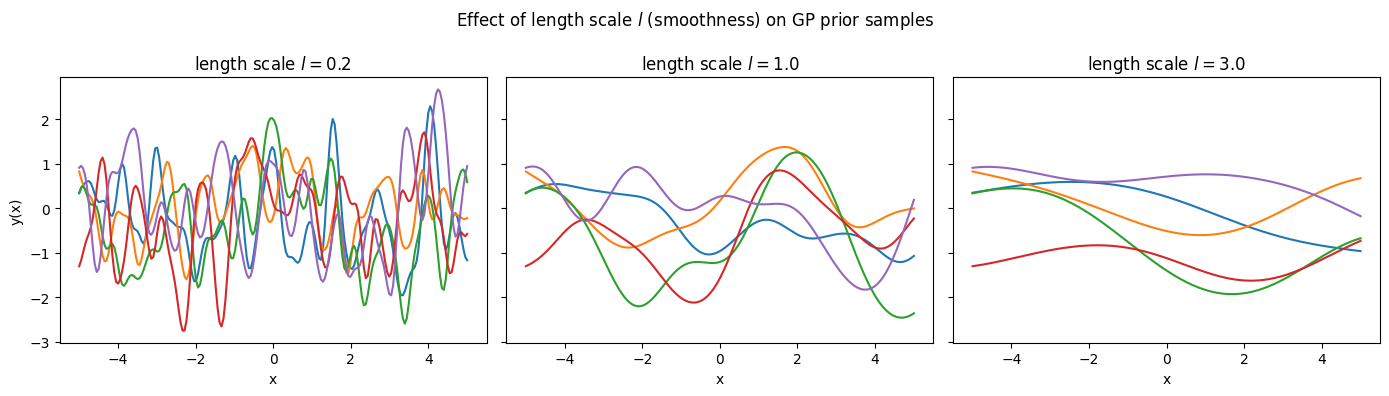

In [7]:
length_scales = [0.2, 1.0, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, l in zip(axes, length_scales):
    samples = sample_gp_prior(x_grid, sigma_f=1.0, length_scale=l, n_samples=5, seed=1)
    ax.plot(x_grid, samples)
    ax.set_title(f"length scale $l={l}$")
    ax.set_xlabel("x")
axes[0].set_ylabel("y(x)")
fig.suptitle("Effect of length scale $l$ (smoothness) on GP prior samples")
plt.tight_layout()
plt.show()

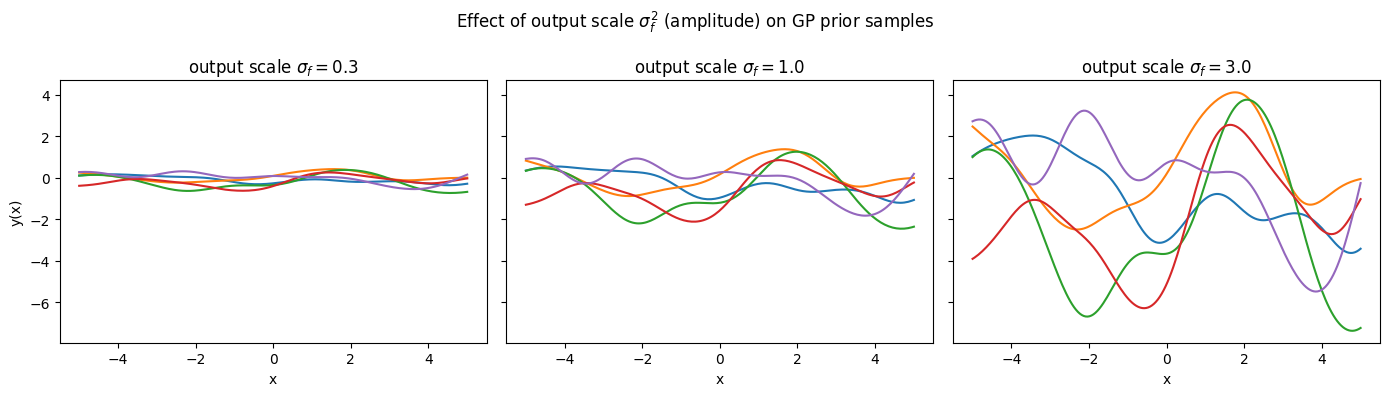

In [8]:
output_scales = [0.3, 1.0, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, sf in zip(axes, output_scales):
    samples = sample_gp_prior(x_grid, sigma_f=sf, length_scale=1.0, n_samples=5, seed=1)
    ax.plot(x_grid, samples)
    ax.set_title(f"output scale $\\sigma_f={sf}$")
    ax.set_xlabel("x")
axes[0].set_ylabel("y(x)")
fig.suptitle("Effect of output scale $\\sigma_f^2$ (amplitude) on GP prior samples")
plt.tight_layout()
plt.show()

$l$ controls how wiggly the functions are allowed to be, $\sigma_f$ controls how *far* they're allowed to wander from zero. Neither of these is set by hand, we will learn both by hyperparameter optimization using the data.

## 6. GP Regression: the Posterior

Now suppose we observe noisy targets $t_n = y(x_n) + \varepsilon_n$, with $\varepsilon_n \sim \mathcal{N}(0, \beta^{-1})$.

Adding gaussian, independent noise to a Gaussian still gives a Gaussian, so the observed targets $\mathbf{t}$ are themselves jointly Gaussian:

$$p(\mathbf{t}) = \mathcal{N}(0, C), \qquad C(x_n, x_m) = k(x_n, x_m) + \beta^{-1}\delta_{nm}$$

$C$ is the same kernel covariance matrix as before, with the noise variance $\beta^{-1}$ added to the diagonal only.

To predict at a new point $x_{N+1}$, write the joint distribution over all $N+1$ targets and condition on the $N$ observed ones. This gives us the predictive mean and variance:

$$m(x_{N+1}) = \mathbf{k}^T C_N^{-1} \mathbf{t}, \qquad \sigma^2(x_{N+1}) = c - \mathbf{k}^T C_N^{-1} \mathbf{k}$$

where $\mathbf{k}$ is the vector of kernel values between $x_{N+1}$ and the training points, and $c = k(x_{N+1},x_{N+1}) + \beta^{-1}$.

**Simply:** 
- The predictive mean is a weighted combination of the observed targets
- The predictive variance is small near training points and grows in regions with no nearby data.

## 7. Code: Fitting a GP to Data

This follows the standard scikit-learn GP regression recipe directly (`GaussianProcessRegressor` + `RBF` kernel).

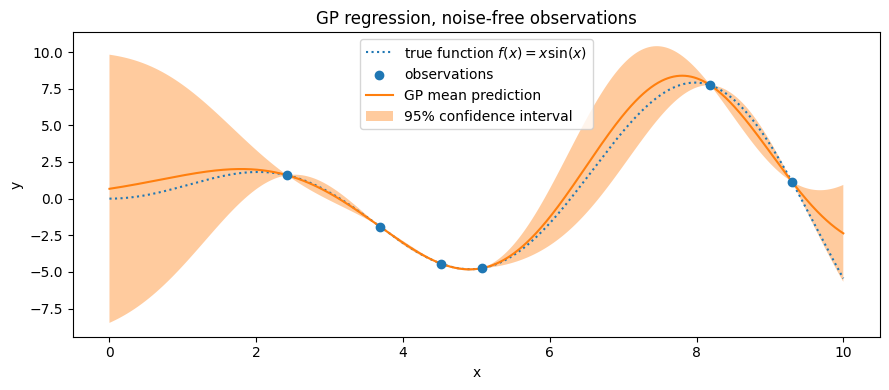

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# toy example: a noise-free function, few observations
def f(x):
    return x * np.sin(x)

X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = f(X).ravel()

rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

kernel = C(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gp.fit(X_train, y_train)

mean_prediction, std_prediction = gp.predict(X, return_std=True)

plt.figure(figsize=(9, 4))
plt.plot(X, y, linestyle="dotted", label=r"true function $f(x)=x\sin(x)$")
plt.scatter(X_train, y_train, label="observations", zorder=3)
plt.plot(X, mean_prediction, label="GP mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.4,
    label="95% confidence interval",
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP regression, noise-free observations")
plt.tight_layout()
plt.show()

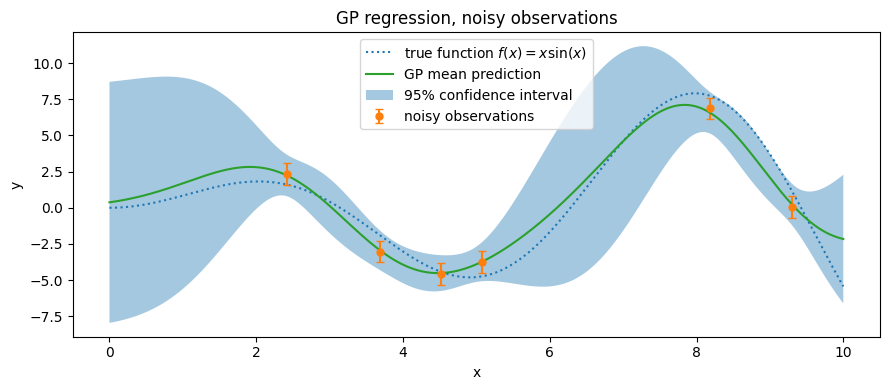

In [15]:
# same setup, but observations are now noisy
noise_std = 0.75
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)

gp_noisy = GaussianProcessRegressor(kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9)
gp_noisy.fit(X_train, y_train_noisy)
mean_prediction, std_prediction = gp_noisy.predict(X, return_std=True)

plt.figure(figsize=(9, 4))
plt.plot(X, y, linestyle="dotted", label=r"true function $f(x)=x\sin(x)$")
plt.errorbar(
    X_train, y_train_noisy, noise_std,
    linestyle="None", marker=".", markersize=10, capsize=3, label="noisy observations",
)
plt.plot(X, mean_prediction, label="GP mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.4,
    label="95% confidence interval",
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP regression, noisy observations")
plt.tight_layout()
plt.show()

## 8. Learning the Hyperparameters

The kernel hyperparameters $(\sigma_f^2, l)$ and the noise precision $\beta$ are not chosen by hand, instead they're fit by maximizing the **log marginal likelihood** of the observed data:

$$\ln p(\mathbf{t}\mid \phi) = -\frac{1}{2}\ln|C_N| - \frac{1}{2}\mathbf{t}^T C_N^{-1}\mathbf{t} - \frac{N}{2}\ln 2\pi$$

This is exactly what `n_restarts_optimizer=9` was doing above. scikit-learn maximized this quantity (via gradient-based optimization) to pick the length scale and output scale you see in the fits.

The gradient used internally is:

$$\frac{\partial \ln p(\mathbf{t}\mid\phi)}{\partial \phi_i} = \frac{1}{2}\mathbf{t}^T C_N^{-1}\frac{\partial C_N}{\partial \phi_i}C_N^{-1}\mathbf{t} - \frac{1}{2}\mathrm{Tr}\!\left(C_N^{-1}\frac{\partial C_N}{\partial \phi_i}\right)$$


In [16]:
print("Fitted kernel (noise-free case):", gp.kernel_)
print("Fitted kernel (noisy case):        ", gp_noisy.kernel_)

Fitted kernel (noise-free case): 5.02**2 * RBF(length_scale=1.43)
Fitted kernel (noisy case):         4.28**2 * RBF(length_scale=1.1)


## Where this is headed

This is the full picture of a "plain" GP: prior over functions, shaped by kernel hyperparameters, updated into a posterior once data comes in. Later we'll build on exactly this by using the GP's posterior mean and its analytic derivatives as a stand-in for numerically integrating an ODE, which is the core idea behind the GP-ODE parameter estimation approach we'll cover next.